In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader
import optuna                               # TODO: implement optuna for hyperparameter optimization

from resources.MLdata import *
from resources.MLfunc import *

# Multilayer Perceptrion (MLP)

## Model

In [3]:
class MLPhlayer(nn.Module):
    def __init__(self, in_size, out_size, norm=None):
        super(MLPhlayer, self).__init__()
        self.norm = norm
        self.fc = nn.Linear(in_size, out_size)
        self.act = nn.ReLU()
        if norm == 'layer':
            self.normL = nn.LayerNorm(out_size)
        elif norm == 'batch':
            self.normL = nn.BatchNorm1d(out_size)
        elif norm == 'instance':
            self.normL = nn.InstanceNorm1d(out_size)
    
    def forward(self, x):
        x = self.fc(x)
        if self.norm:
            x = self.normL(x)
        x = self.act(x)
        return x

class MLP(nn.Module):
    def __init__(self, in_size, h_size, out_size, norm=None):
        super(MLP, self).__init__()
        self.norm = norm
        self.fcIN = nn.Linear(in_size, h_size[0])
        self.fcOUT = nn.Linear(h_size[-1], out_size)
        self.act = nn.ReLU()
        if norm == 'layer':
            self.normL = nn.LayerNorm(h_size[0])
        if norm == 'batch':
            self.normL = nn.BatchNorm1d(h_size[0])
        if norm == 'instance':
            self.normL = nn.InstanceNorm1d(h_size[0])
        self.dropout = nn.Dropout(0.25)
        self.hlayers = nn.ModuleList([
            MLPhlayer(i, j, norm) for i, j in zip(h_size[:-1], h_size[1:])])

    def forward(self, x):
        x = self.fcIN(x)
        if self.norm:
            x = self.normL(x)
        x = self.act(x)
        for layer in self.hlayers:
            x = layer(x)
        x = self.fcOUT(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")                                         # TODO: implement gpu

Using device: cpu


# Stress-Strain Curve Optimization
General approximation from change in node coordinate components to change in stress-strain curve.

In [4]:
DAT = DATA(load=True)

In [5]:
in_size = DAT.train_in.shape[-1]
out_size = DAT.train_out.shape[-1]
h_size = [128]*3

BATCH_SIZE = 256
LEARNING_RATE = 1e-3
n_epochs = 500

In [6]:
trainDS = Dataset_(DAT.train_in, DAT.train_outST)
valDS = Dataset_(DAT.val_in, DAT.val_outST)
testDS = Dataset_(DAT.test_in, DAT.test_outST)

train_dataloader = DataLoader(dataset=trainDS, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(dataset=valDS, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=testDS, batch_size=BATCH_SIZE, shuffle=False)

In [7]:
mlp1 = MLP(in_size, h_size, out_size, norm="layer").to(device)
mlp1.apply(weights_init)

opt = optim.Adam(mlp1.parameters(), lr=LEARNING_RATE, weight_decay=1e-5) 
lossf = nn.MSELoss()

earlyStop = EarlyStopping(patience=30, min_delta=1e-4, verbose=True)

ReduceLR = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.7, patience=6, threshold=1e-4, verbose=True)
OneCycleLR = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=1e-3, steps_per_epoch=len(train_dataloader), epochs=n_epochs)
CosineAnnealingLR = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

In [8]:
mlp1, epoch, train_lossLog, val_lossLog = train_model("mpl", mlp1, lossf, n_epochs, opt, train_dataloader, 
                                                      val_dataloader=val_dataloader, scheduler=ReduceLR, 
                                                      earlyStop=earlyStop, verbose=10)

Epoch: 1 - Loss: 0.584202766418457
Epoch: 10 - Loss: 0.22682808339595795
Epoch: 20 - Loss: 0.09155663847923279
Epoch: 30 - Loss: 0.04575623944401741
Epoch: 40 - Loss: 0.030447764322161674
Epoch: 50 - Loss: 0.021999888122081757
Epoch: 60 - Loss: 0.01729550212621689
Epoch: 70 - Loss: 0.014766181819140911
Epoch: 80 - Loss: 0.012895121239125729
Epoch: 90 - Loss: 0.011395297944545746
Epoch: 100 - Loss: 0.009954659268260002
Epoch: 110 - Loss: 0.008316009305417538
Epoch: 120 - Loss: 0.008266560733318329
Epoch: 130 - Loss: 0.008304711431264877
Epoch: 140 - Loss: 0.007358672097325325
Epoch: 150 - Loss: 0.007190105505287647
Epoch: 160 - Loss: 0.007146001793444157
Epoch: 170 - Loss: 0.00645836116746068
Epoch: 180 - Loss: 0.006117904558777809
Epoch: 190 - Loss: 0.006094835232943296
Epoch: 200 - Loss: 0.005677550565451384
Epoch 00210: reducing learning rate of group 0 to 2.8000e-05.
Epoch: 210 - Loss: 0.0054491846822202206
Epoch: 220 - Loss: 0.005211846437305212
Epoch: 230 - Loss: 0.005991596728563

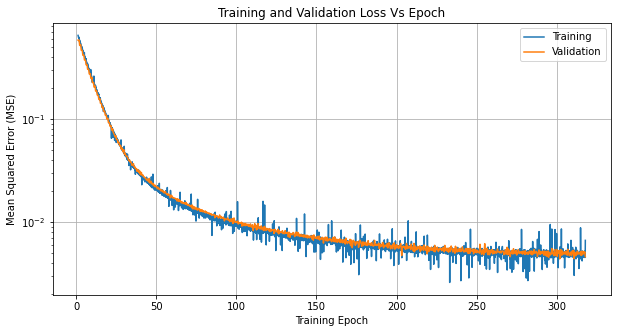

In [10]:
plot_loss(epoch, train_lossLog, val_lossLog)

In [62]:
test_outputs = predict_model("mlp", mlp1, test_dataloader)
test_outputs = standardize(test_outputs, DAT.outParams[0], DAT.outParams[1], mode=1)

In [63]:
err = list(abs(sum(DAT.test_out - test_outputs)))
err.index(min(err)), err.index(max(err))

(147, 81)

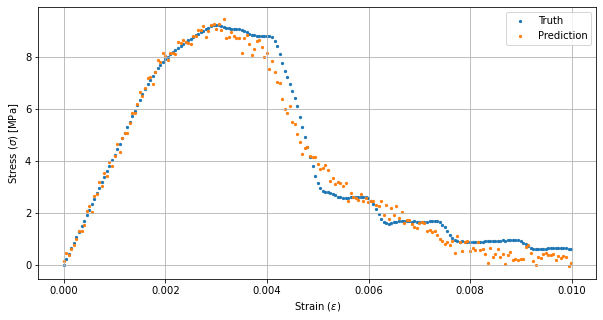

In [64]:
plot_StressStrainOUT(DAT.perOUT, DAT.train_out, test_outputs, indx=103)

# Distribution Function Optimization
Unique function approximations from perfect lattice coorindates to each disorder ($\Delta$) distribution.

### Version 1
$[x_i, y_i] \to \delta x_i$  
$[x_i, y_i] \to \delta y_i$

In [13]:
DAT1 = DATA(load=True, format=1)

In [14]:
DAT1.train_in1.shape, DAT1.dx_out1.shape

((357, 2), (3588, 357, 1))

In [15]:
in_size = DAT1.train_in1.shape[-1]
out_size = DAT1.dx_out1.shape[-1]
h_size = [10, 100, 100, 10]

BATCH_SIZE = 1
LEARNING_RATE = 1e-3
n_epochs = 10

In [16]:
trainDS1x = Dataset_(DAT1.train_in1, DAT1.dx_out1[0])
trainDS1y = Dataset_(DAT1.train_in1, DAT1.dy_out1[0])

train1x_dataloader = DataLoader(dataset=trainDS1x, batch_size=BATCH_SIZE, shuffle=True)
train1y_dataloader = DataLoader(dataset=trainDS1y, batch_size=BATCH_SIZE, shuffle=True)

test1x_dataloader = DataLoader(dataset=trainDS1x, batch_size=BATCH_SIZE, shuffle=False)
test1y_dataloader = DataLoader(dataset=trainDS1y, batch_size=BATCH_SIZE, shuffle=False)

In [17]:
mlp2 = MLP(in_size, h_size, out_size).to(device)
mlp2.apply(weights_init)

opt = optim.Adam(mlp2.parameters(), lr=LEARNING_RATE)
lossf = nn.MSELoss()

earlyStop = EarlyStopping(patience=50, min_delta=1e-4, verbose=True)

ReduceLR = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.2427, patience=10, threshold=1e-4, verbose=True)
OneCycleLR = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=1e-3, steps_per_epoch=len(train1x_dataloader), epochs=n_epochs)
CosineAnnealingLR = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

In [18]:
mlp2, epoch, train_lossLog, val_lossLog = train_model("mlp", mlp2, lossf, n_epochs, opt, train1x_dataloader, test1x_dataloader, scheduler=ReduceLR, earlyStop=earlyStop)

Epoch: 1 - Loss: 2.2237629890441895
Epoch: 10 - Loss: 1.8167110681533813
Best Epoch: 10, with loss 1.8167110681533813


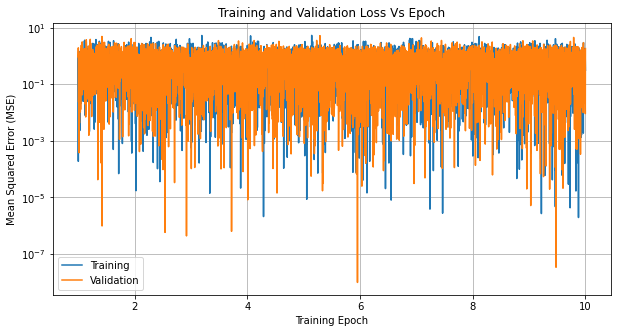

In [19]:
plot_loss(epoch, train_lossLog, val_lossLog)

In [20]:
test_outputs = predict_model("mlp", mlp2, test1x_dataloader)
max(test_outputs[:,0] - DAT1.dx_out1[0,:,0]), min(test_outputs[:,0] - DAT1.dx_out1[0,:,0])

(1.7036106323471074, -2.119821134641266)

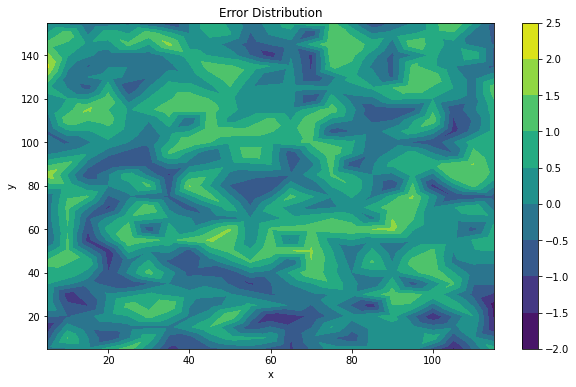

In [21]:
plot_Distribution(DAT1.train_in1, test_outputs[:,0], dx_out1=DAT1.dx_out1[0,:,0], typ="contour")

### Version 2
$[x_1, y_2, ..., x_n, y_n] \to [\delta x_i, ..., \delta x_n]$  
$[x_1, y_2, ..., x_n, y_n] \to [\delta y_i, ..., \delta y_n]$


In [22]:
DAT2 = DATA(load=True, format=2)

In [23]:
DAT2.train_in2.shape, DAT2.dx_out2.shape

((2, 714), (3588, 2, 357))

In [24]:
in_size = DAT2.train_in2.shape[-1]
out_size = DAT2.dx_out2.shape[-1]
h_size = [2**10]

BATCH_SIZE = 8
LEARNING_RATE = 9e-4
n_epochs = 10000

In [25]:
trainDS1x = Dataset_(DAT2.train_in2, DAT2.dx_out2[0])
trainDS1y = Dataset_(DAT2.train_in2, DAT2.dy_out2[0])

train1x_dataloader = DataLoader(dataset=trainDS1x, batch_size=BATCH_SIZE, shuffle=True)
train1y_dataloader = DataLoader(dataset=trainDS1y, batch_size=BATCH_SIZE, shuffle=True)

test1x_dataloader = DataLoader(dataset=trainDS1x, batch_size=BATCH_SIZE, shuffle=False)
test1y_dataloader = DataLoader(dataset=trainDS1y, batch_size=BATCH_SIZE, shuffle=False)

In [26]:
mlp3 = MLP(in_size, h_size, out_size).to(device)
mlp3.apply(weights_init)

opt = optim.Adam(mlp3.parameters(), lr=LEARNING_RATE)
lossf = nn.MSELoss()

earlyStop = EarlyStopping(patience=100, min_delta=1e-11, verbose=True)

ReduceLR = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.2427, patience=16, threshold=1e-4, verbose=True)
OneCycleLR = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=1e-3, steps_per_epoch=len(train1x_dataloader), epochs=n_epochs)
CosineAnnealingLR = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

In [27]:
mlp3, epoch, train_lossLog, val_lossLog = train_model("mlp", mlp3, lossf, n_epochs, opt, train1x_dataloader, test1x_dataloader, scheduler=ReduceLR, earlyStop=earlyStop)

Epoch: 1 - Loss: 3647.002197265625
Epoch: 10 - Loss: 1410.0670166015625
Epoch: 20 - Loss: 420.9021911621094
Epoch: 30 - Loss: 103.36817169189453
Epoch: 40 - Loss: 24.328508377075195
Epoch: 50 - Loss: 10.462024688720703
Epoch: 60 - Loss: 7.437941074371338
Epoch: 70 - Loss: 2.2957139015197754
Epoch: 80 - Loss: 1.1170839071273804
Epoch: 90 - Loss: 0.5941230058670044
Epoch: 100 - Loss: 0.2835444211959839
Epoch: 110 - Loss: 0.09551610797643661
Epoch: 120 - Loss: 0.05800916999578476
Epoch: 130 - Loss: 0.03178532421588898
Epoch: 140 - Loss: 0.016809845343232155
Epoch: 150 - Loss: 0.00961372535675764
Epoch: 160 - Loss: 0.008673815056681633
Epoch: 170 - Loss: 0.008171537891030312
Epoch: 180 - Loss: 0.005548952147364616
Epoch: 190 - Loss: 0.0033742652740329504
Epoch: 200 - Loss: 0.0028419685550034046
Epoch: 210 - Loss: 0.007617119699716568
Epoch 00215: reducing learning rate of group 0 to 9.7080e-06.
Epoch: 220 - Loss: 0.004459319170564413
Epoch: 230 - Loss: 0.001608160207979381
Epoch: 240 - Los

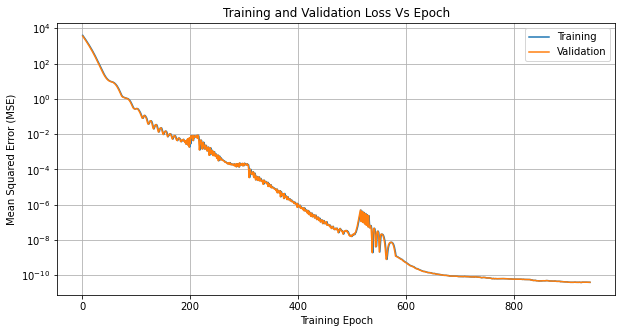

In [28]:
plot_loss(epoch, train_lossLog, val_lossLog)

In [29]:
test_outputs = predict_model("mlp", mlp3, test1x_dataloader)
max(abs(test_outputs[0] - DAT2.dx_out2[0,0])), min(abs(test_outputs[0] - DAT2.dx_out2[0,0]))

(2.0422874456471618e-05, 6.375747663156517e-08)

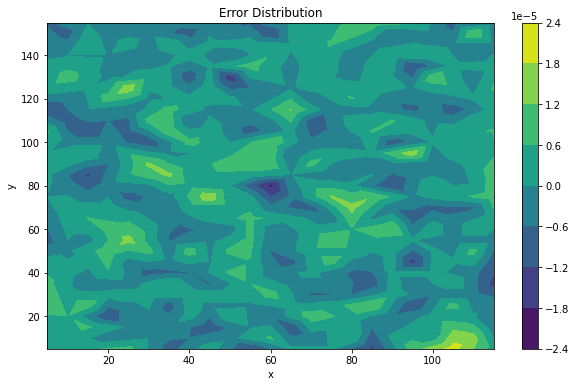

In [33]:
plot_Distribution(DAT2.train_in1, test_outputs[0], dx_out1=DAT2.dx_out2[0,0], typ="contour")

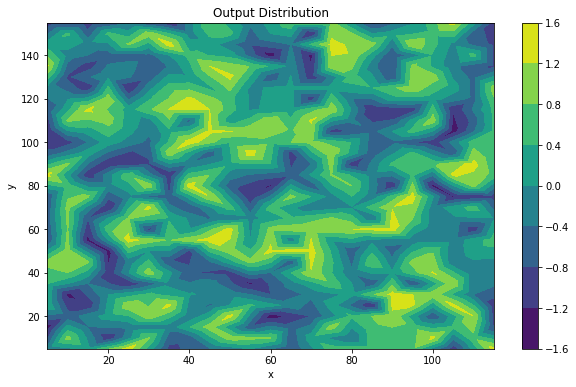

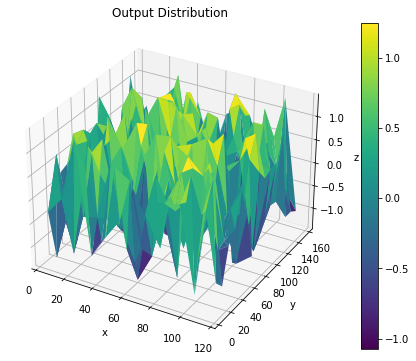

In [31]:
plot_Distribution(DAT2.train_in1, test_outputs[0], typ="both")

In [32]:
for name, param in mlp3.state_dict().items():
    print(f"{name}: {param.shape}\n{param}\n")

fcIN.weight: torch.Size([1024, 714])
tensor([[ 0.0166, -0.0304,  0.0410,  ..., -0.0201, -0.0159, -0.0061],
        [-0.0128,  0.0430,  0.0017,  ...,  0.0146, -0.0219, -0.0403],
        [-0.0025,  0.0030, -0.0446,  ..., -0.0739,  0.0693, -0.0256],
        ...,
        [ 0.0166, -0.0014,  0.0101,  ..., -0.0443,  0.0648,  0.0184],
        [-0.0427, -0.0962,  0.0272,  ...,  0.0555,  0.0624,  0.0266],
        [-0.0120, -0.0247,  0.0435,  ..., -0.0240,  0.0359,  0.0123]])

fcIN.bias: torch.Size([1024])
tensor([ 0.0003, -0.0012, -0.0004,  ...,  0.0000,  0.0000, -0.0022])

fcOUT.weight: torch.Size([357, 1024])
tensor([[-0.0565,  0.0186, -0.0043,  ..., -0.0475, -0.0572, -0.0382],
        [-0.0284,  0.0041, -0.0047,  ...,  0.0168, -0.0693, -0.0474],
        [ 0.0047,  0.0206,  0.0318,  ...,  0.0325,  0.0329,  0.0116],
        ...,
        [-0.0042, -0.0116,  0.0518,  ..., -0.0482, -0.0007,  0.0442],
        [-0.0173,  0.0357, -0.0100,  ...,  0.0571,  0.0796,  0.0377],
        [-0.0778, -0.0070, 